In [2]:
#LIBRARIES IMPORT
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
df = pd.read_csv('Resume.csv')

print("Dataset size:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPehli 3 rows:")
df.head(3)

Dataset size: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

Pehli 3 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:

df = df[['Resume_str', 'Category']]

print("Categories count:")
print(df['Category'].value_counts())
print("\nTotal categories:", df['Category'].nunique())
print("\nExact category names:")
print(df['Category'].unique())

Categories count:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Total categories: 24

Exact category names:
['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' '

In [6]:

stop_words = set(stopwords.words('english'))

def clean_text(text):
    try:
        text = text.lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\S+@\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        tokens = text.split()
        tokens = [w for w in tokens if w not in stop_words]
        return ' '.join(tokens)
    except:
        return ''

df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

print("Text cleaning ho gayi!")
print("\nResume Sample(first300 characters):")
print(df['Resume_str'][0][:300])
print("\nAfter Cleaning:")
print(df['cleaned_resume'][0][:300])

Text cleaning ho gayi!

Resume Sample(first300 characters):
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

After Cleaning:
hr administratormarketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customerfocused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisfac


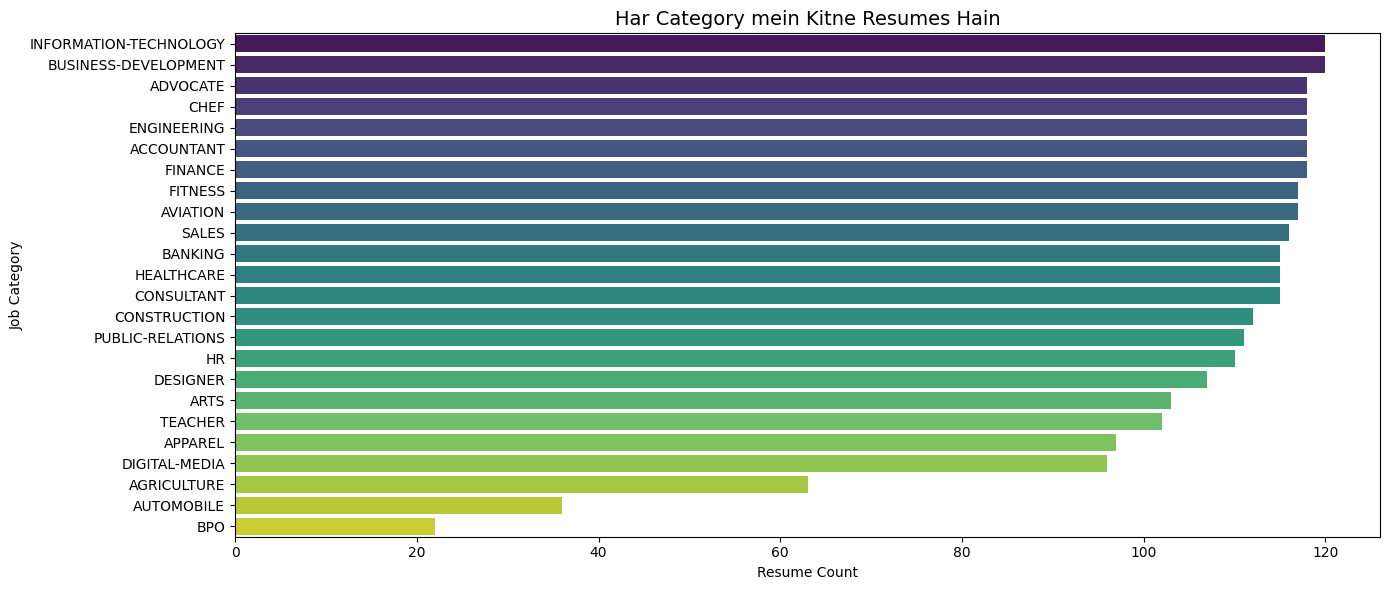

In [7]:
plt.figure(figsize=(14, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Har Category mein Kitne Resumes Hain', fontsize=14)
plt.xlabel('Resume Count')
plt.ylabel('Job Category')
plt.tight_layout()
plt.show()

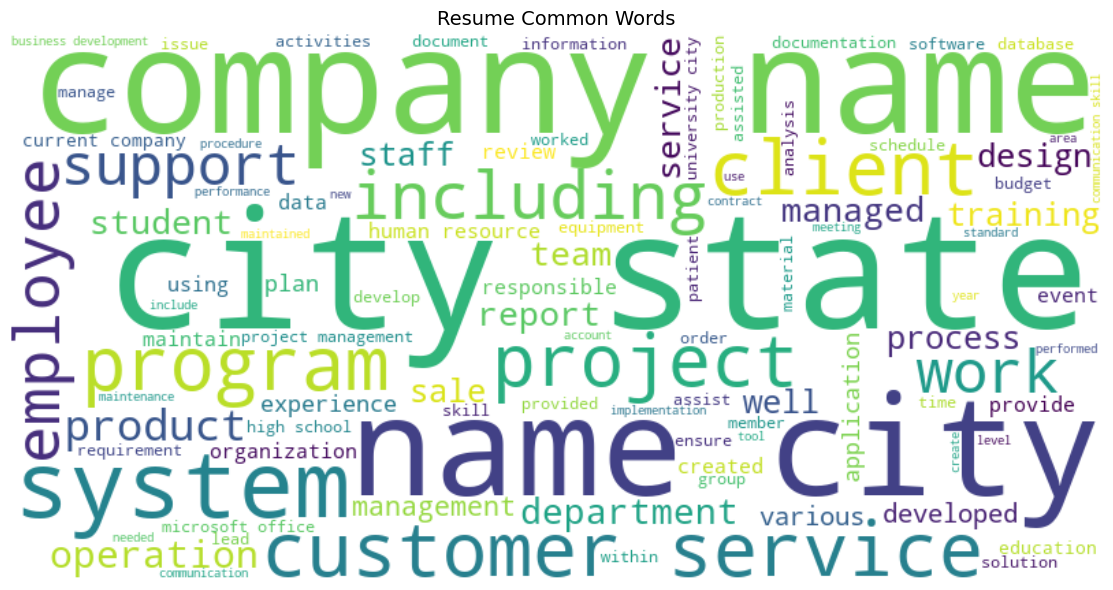

In [8]:
all_text = ' '.join(df['cleaned_resume'].values)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Resume Common Words', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:

le = LabelEncoder()
df['Category_num'] = le.fit_transform(df['Category'])

print("Categories aur unke numbers:")
for i, cat in enumerate(le.classes_):
    print(f"  {i} → {cat}")

tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df['cleaned_resume'])
y = df['Category_num']

print(f"\nTF-IDF matrix ka size: {X.shape}")

Categories aur unke numbers:
  0 → ACCOUNTANT
  1 → ADVOCATE
  2 → AGRICULTURE
  3 → APPAREL
  4 → ARTS
  5 → AUTOMOBILE
  6 → AVIATION
  7 → BANKING
  8 → BPO
  9 → BUSINESS-DEVELOPMENT
  10 → CHEF
  11 → CONSTRUCTION
  12 → CONSULTANT
  13 → DESIGNER
  14 → DIGITAL-MEDIA
  15 → ENGINEERING
  16 → FINANCE
  17 → FITNESS
  18 → HEALTHCARE
  19 → HR
  20 → INFORMATION-TECHNOLOGY
  21 → PUBLIC-RELATIONS
  22 → SALES
  23 → TEACHER

TF-IDF matrix ka size: (2484, 3000)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data:  {X_train.shape[0]} resumes")
print(f"Testing data:   {X_test.shape[0]} resumes")

Training data:  1987 resumes
Testing data:   497 resumes


In [11]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    C=5,
    solver='lbfgs',
)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, lr_pred, target_names=le.classes_))

Logistic Regression Accuracy: 69.82%

Detailed Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.77      0.83      0.80        24
              ADVOCATE       0.45      0.62      0.53        24
           AGRICULTURE       1.00      0.46      0.63        13
               APPAREL       0.71      0.26      0.38        19
                  ARTS       0.40      0.29      0.33        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.86      0.75      0.80        24
               BANKING       0.89      0.74      0.81        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.66      0.88      0.75        24
                  CHEF       0.89      0.67      0.76        24
          CONSTRUCTION       0.74      0.77      0.76        22
            CONSULTANT       0.59      0.43      0.50        23
              DESIGNER       0.90      0.90     

In [12]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy: {nb_accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, nb_pred, target_names=le.classes_))

Naive Bayes Accuracy: 55.94%

Detailed Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.53      0.88      0.66        24
              ADVOCATE       0.35      0.46      0.40        24
           AGRICULTURE       1.00      0.08      0.14        13
               APPAREL       0.00      0.00      0.00        19
                  ARTS       0.00      0.00      0.00        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.83      0.62      0.71        24
               BANKING       0.87      0.57      0.68        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.39      0.79      0.52        24
                  CHEF       0.83      0.79      0.81        24
          CONSTRUCTION       0.65      0.68      0.67        22
            CONSULTANT       0.50      0.04      0.08        23
              DESIGNER       0.76      0.62      0.68   

In [13]:

svc_model = LinearSVC(random_state=42, max_iter=2000, C=1.0)
svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)
svc_accuracy = accuracy_score(y_test, svc_pred)

print(f"Linear SVC Accuracy: {svc_accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, svc_pred, target_names=le.classes_))

Linear SVC Accuracy: 72.84%

Detailed Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.70      0.88      0.78        24
              ADVOCATE       0.68      0.71      0.69        24
           AGRICULTURE       1.00      0.54      0.70        13
               APPAREL       0.56      0.26      0.36        19
                  ARTS       0.62      0.38      0.47        21
            AUTOMOBILE       1.00      0.43      0.60         7
              AVIATION       0.82      0.75      0.78        24
               BANKING       0.78      0.78      0.78        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.72      0.88      0.79        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.78      0.82      0.80        22
            CONSULTANT       0.64      0.39      0.49        23
              DESIGNER       0.91      0.95      0.93    

In [14]:

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

Random Forest Accuracy: 75.25%

Detailed Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.72      0.96      0.82        24
              ADVOCATE       0.81      0.71      0.76        24
           AGRICULTURE       1.00      0.31      0.47        13
               APPAREL       0.89      0.42      0.57        19
                  ARTS       0.50      0.14      0.22        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.81      0.88      0.84        24
               BANKING       0.74      0.61      0.67        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.82      0.96      0.88        24
                  CHEF       0.91      0.88      0.89        24
          CONSTRUCTION       0.88      0.95      0.91        22
            CONSULTANT       0.73      0.48      0.58        23
              DESIGNER       0.88      1.00      0.93 

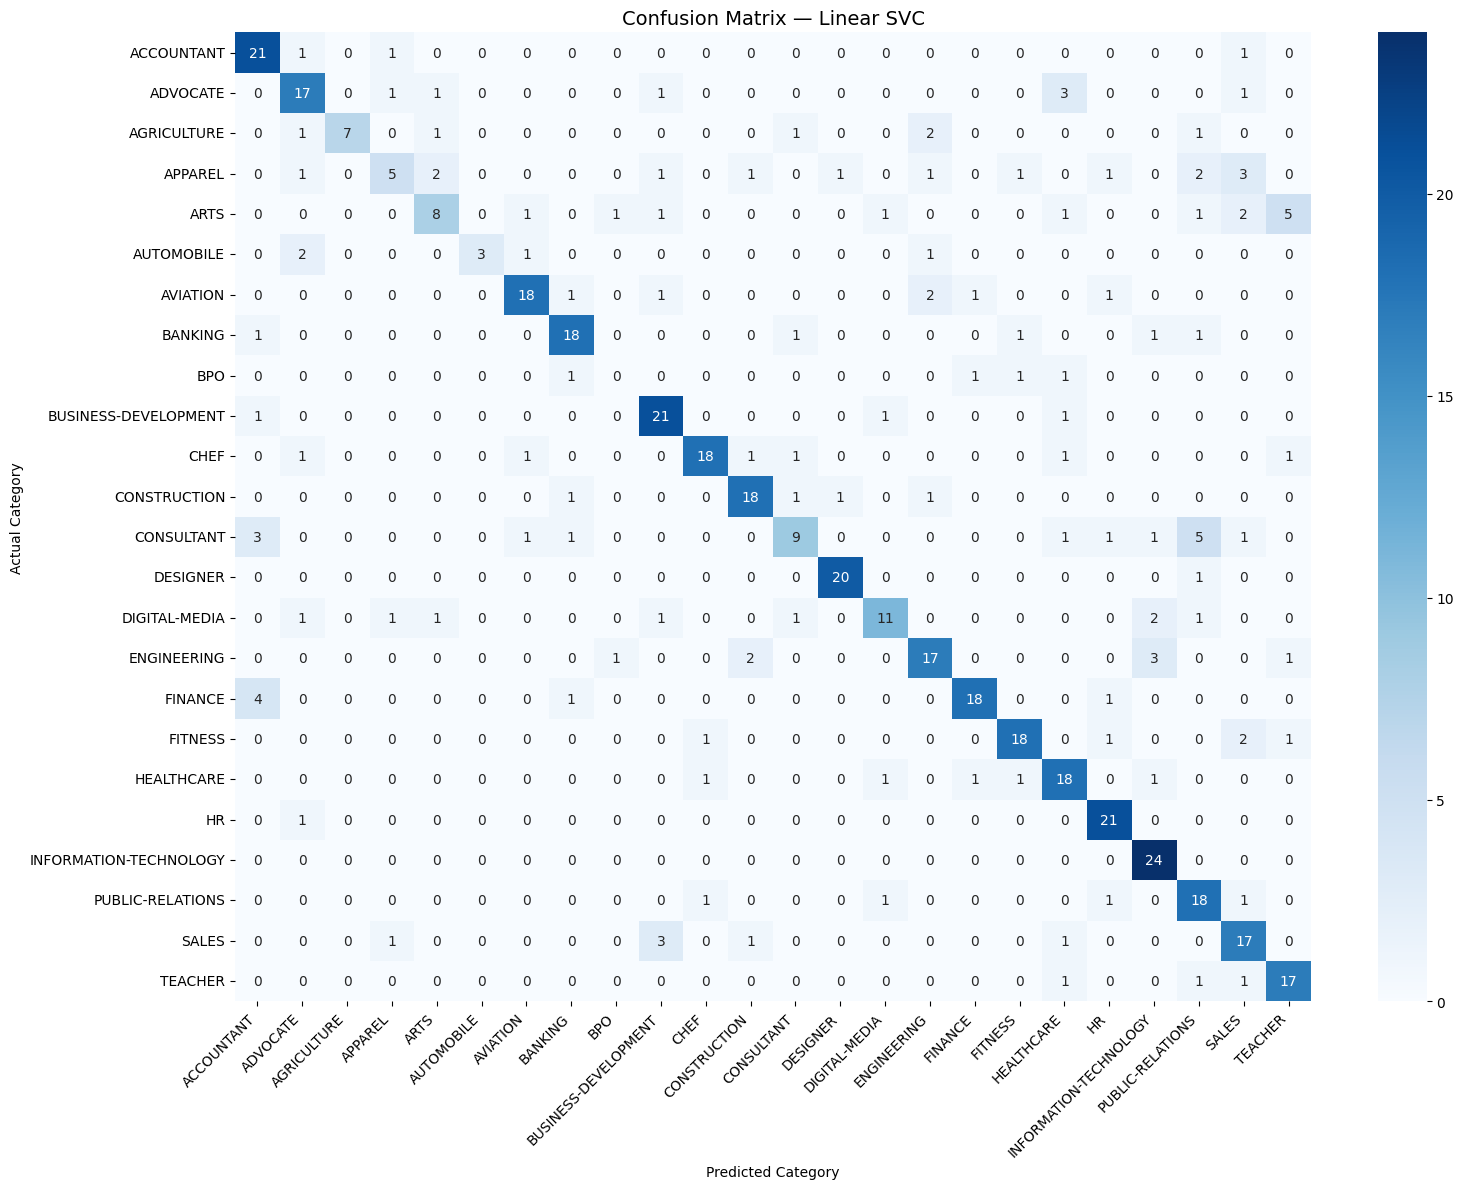

In [15]:
plt.figure(figsize=(16, 12))
cm_svc = confusion_matrix(y_test, svc_pred)
sns.heatmap(cm_svc,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Linear SVC', fontsize=14)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

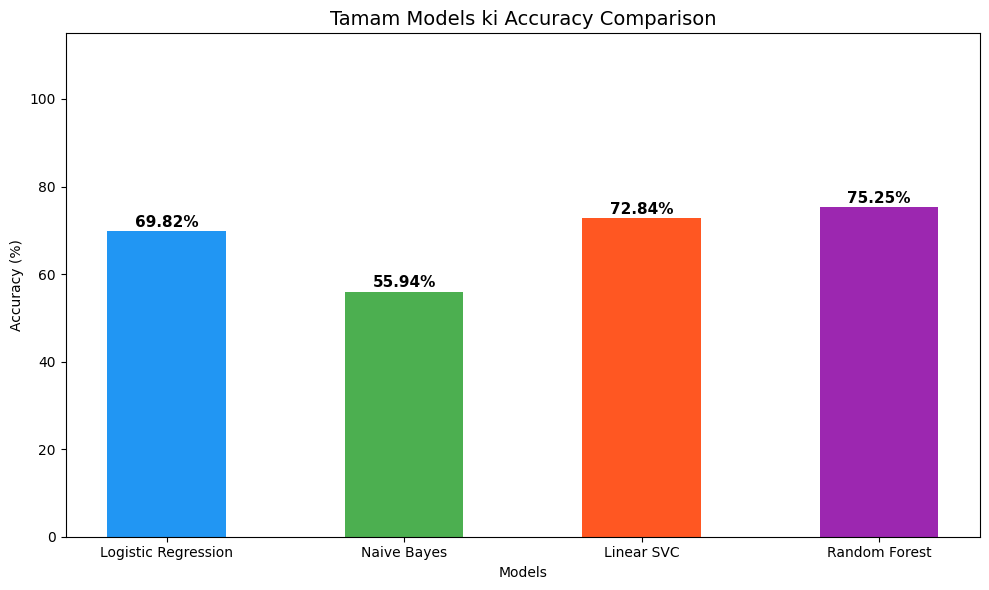


--- Final Results ---
Random Forest             75.25%
Linear SVC                72.84%
Logistic Regression       69.82%
Naive Bayes               55.94%

Best Model: Random Forest — 75.25%


In [16]:
models = ['Logistic Regression', 'Naive Bayes', 'Linear SVC', 'Random Forest']
accuracies = [
    lr_accuracy * 100,
    nb_accuracy * 100,
    svc_accuracy * 100,
    rf_accuracy * 100
]

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylim(0, 115)
plt.title('Tamam Models ki Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{acc:.2f}%',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

print("\n--- Final Results ---")
results = {
    'Logistic Regression': lr_accuracy * 100,
    'Naive Bayes':         nb_accuracy * 100,
    'Linear SVC':          svc_accuracy * 100,
    'Random Forest':       rf_accuracy * 100,
}
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model:<25} {acc:.2f}%")

best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} — {results[best_model]:.2f}%")

In [17]:
def predict_resume(resume_text):
    cleaned = clean_text(resume_text)
    vectorized = tfidf.transform([cleaned])

    lr_result  = le.inverse_transform(lr_model.predict(vectorized))[0]
    nb_result  = le.inverse_transform(nb_model.predict(vectorized))[0]
    svc_result = le.inverse_transform(svc_model.predict(vectorized))[0]
    rf_result  = le.inverse_transform(rf_model.predict(vectorized))[0]

    print("=" * 45)
    print("       RESUME CATEGORY PREDICTION")
    print("=" * 45)
    print(f"  Logistic Regression : {lr_result}")
    print(f"  Naive Bayes         : {nb_result}")
    print(f"  Linear SVC          : {svc_result}")
    print(f"  Random Forest       : {rf_result}")
    print("=" * 45)

# TEST 1 — INFORMATION TECHNOLOGY

print("\nTEST 1: IT Resume")
predict_resume("""
Software engineer with 4 years experience in Python, Java, JavaScript.
Developed web applications using Django, React, Node.js and REST APIs.
Managed databases MySQL and MongoDB. Deployed applications on AWS and Docker.
Experience in agile development, Git version control and CI/CD pipelines.
Bachelor in Computer Science. Skills: Linux, networking, cloud computing.
""")


# TEST 2 — FINANCE

print("\nTEST 2: Finance Resume")
predict_resume("""
Finance professional with 5 years experience in financial analysis and accounting.
Expertise in budgeting, forecasting, financial statements and investment analysis.
Proficient in Excel, SAP, QuickBooks and financial modeling.
CFA certified. Experience in tax planning, auditing and risk management.
Strong knowledge of banking regulations and corporate finance.
""")


# TEST 3 — HR

print("\nTEST 3: HR Resume")
predict_resume("""
Human Resources manager with 6 years experience in talent acquisition and recruitment.
Expert in employee relations, performance management and training development.
Conducted interviews, managed payroll and handled employee grievances.
Knowledge of labor laws, HR policies and organizational development.
Skills: onboarding, compensation planning, HRIS systems, team building.
""")


# TEST 4 — ENGINEERING

print("\nTEST 4: Engineering Resume")
predict_resume("""
Mechanical engineer with experience in design, manufacturing and quality control.
Proficient in AutoCAD, SolidWorks and MATLAB for engineering design projects.
Worked on structural analysis, thermodynamics and fluid mechanics problems.
Experience in project management, maintenance planning and process optimization.
Skills: CNC machining, welding, 3D modeling, production planning.
""")


TEST 1: IT Resume
       RESUME CATEGORY PREDICTION
  Logistic Regression : ENGINEERING
  Naive Bayes         : INFORMATION-TECHNOLOGY
  Linear SVC          : ENGINEERING
  Random Forest       : BUSINESS-DEVELOPMENT

TEST 2: Finance Resume
       RESUME CATEGORY PREDICTION
  Logistic Regression : FINANCE
  Naive Bayes         : FINANCE
  Linear SVC          : FINANCE
  Random Forest       : FINANCE

TEST 3: HR Resume
       RESUME CATEGORY PREDICTION
  Logistic Regression : HR
  Naive Bayes         : HR
  Linear SVC          : HR
  Random Forest       : HR

TEST 4: Engineering Resume
       RESUME CATEGORY PREDICTION
  Logistic Regression : ENGINEERING
  Naive Bayes         : ENGINEERING
  Linear SVC          : ENGINEERING
  Random Forest       : ENGINEERING


In [18]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Better TF-IDF
tfidf_v2 = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    max_df=0.90
)

X_v2 = tfidf_v2.fit_transform(df['cleaned_resume'])
y_v2 = df['Category_num']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

# Model 1 — Linear SVC tuned
svc_v2 = LinearSVC(C=0.5, max_iter=3000, random_state=42)
svc_v2.fit(X_train_v2, y_train_v2)
svc_v2_acc = accuracy_score(y_test_v2, svc_v2.predict(X_test_v2))

# Model 2 — Random Forest tuned  
rf_v2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf_v2.fit(X_train_v2, y_train_v2)
rf_v2_acc = accuracy_score(y_test_v2, rf_v2.predict(X_test_v2))

# Model 3 — Logistic Regression tuned
lr_v2 = LogisticRegression(
    C=10,
    max_iter=3000,
    random_state=42,
    solver='lbfgs',

)
lr_v2.fit(X_train_v2, y_train_v2)
lr_v2_acc = accuracy_score(y_test_v2, lr_v2.predict(X_test_v2))

print("=" * 45)
print("    TUNED MODELS — FINAL RESULTS")
print("=" * 45)
print(f"  Linear SVC (tuned)          : {svc_v2_acc*100:.2f}%")
print(f"  Random Forest (tuned)       : {rf_v2_acc*100:.2f}%")
print(f"  Logistic Regression (tuned) : {lr_v2_acc*100:.2f}%")
print("=" * 45)

best = max([
    ('Linear SVC', svc_v2_acc),
    ('Random Forest', rf_v2_acc),
    ('Logistic Regression', lr_v2_acc)
], key=lambda x: x[1])

print(f"\n  Best Model: {best[0]} — {best[1]*100:.2f}%")

    TUNED MODELS — FINAL RESULTS
  Linear SVC (tuned)          : 72.64%
  Random Forest (tuned)       : 76.86%
  Logistic Regression (tuned) : 70.62%

  Best Model: Random Forest — 76.86%


In [21]:
import pickle

# Sab models aur objects save karo
with open('models.pkl', 'wb') as f:
    pickle.dump({
        'tfidf': tfidf,
        'lr_model': lr_model,
        'nb_model': nb_model,
        'svc_model': svc_model,
        'rf_model': rf_model,
        'label_encoder': le
    }, f)
